# Bài 17: Mảng N-chiều cho dữ liệu raster với xarray

XArray là thư viện Python mạnh mẽ cho việc xử lý dữ liệu mảng N-chiều có nhãn, đặc biệt thiết yếu cho phân tích không gian và khoa học khí hậu.

## 17.1. Mục tiêu học tập

Sau khi hoàn thành bài học này, bạn sẽ có thể:

- Hiểu cấu trúc XArray - Dataset, DataArray và coordinate systems
- Thao tác trên dữ liệu nhiều chiều
- Thực hiện indexing và lựa chọn theo chiều địa lý và thời gian
- Áp dụng tính toán và thống kê cho dữ liệu đa chiều
- Sử dụng các phương thức nhóm cho dữ liệu theo thời gian 
- Tích hợp các hàm nâng cao `apply_ufunc` hoặc các hàm thủ công.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd

## 17.2. Cấu trúc Dữ liệu XArray Cơ bản


Trong thực tế, dữ liệu khoa học thường không chỉ bao gồm các giá trị số mà còn đi kèm với thông tin mô tả như thời gian, vị trí hoặc các chiều dữ liệu khác. Xarray được thiết kế để quản lý loại dữ liệu này một cách trực quan thông qua các chiều (dimensions) và tọa độ (coordinates).

XArray có **2 cấu trúc dữ liệu chính** là `DataArray` và `Dataset`:

**DataArray - Mảng đa chiều có nhãn**
- **Khái niệm**: Như NumPy array nhưng có coordinates và labels
- **Thành phần**: `data` + `dimensions` + `coordinates` + `attributes`
- **Ứng dụng**: Biến đơn lẻ (nhiệt độ, mưa, NDVI) trong không gian-thời gian

**Dataset - Tập hợp nhiều DataArrays**  
- **Khái niệm**: Như DataFrame của Pandas nhưng cho dữ liệu đa chiều
- **Thành phần**: Nhiều DataArrays có chung coordinates system
- **Ứng dụng**: Datasets khí hậu hoàn chỉnh (temp + rainfall + humidity + wind)

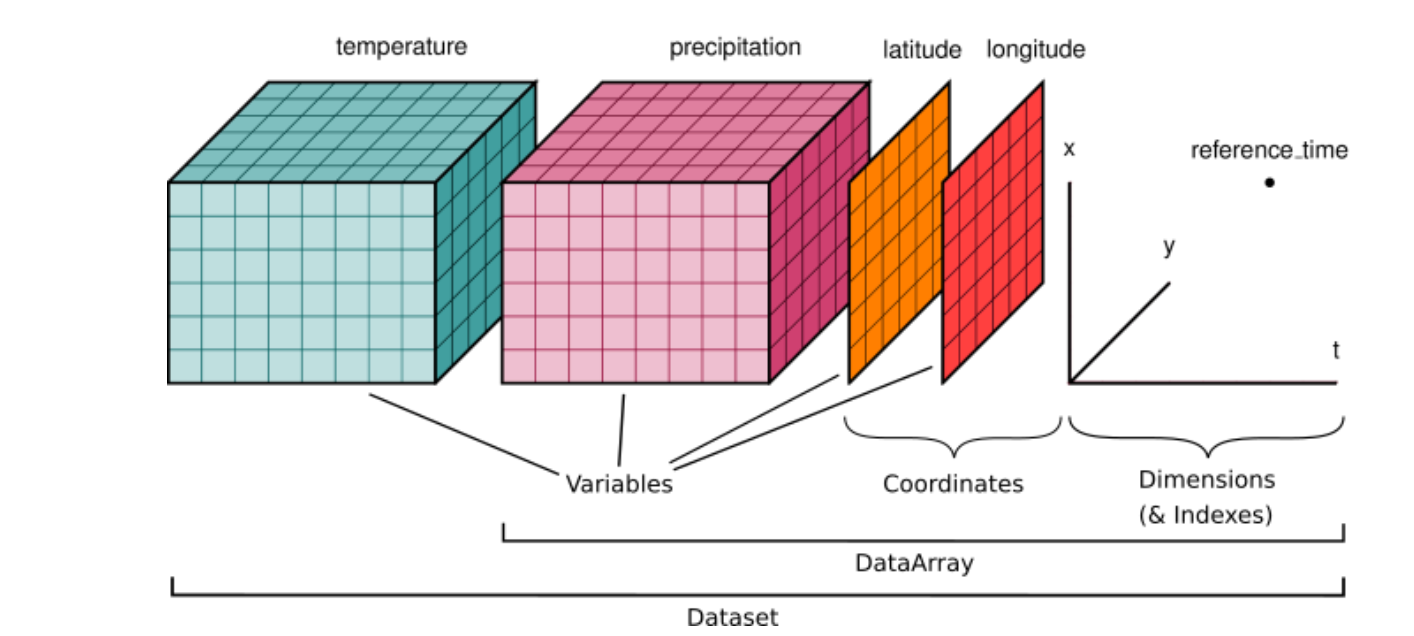

### 17.2.1. Tạo `DataArray` đơn giản

DataArray là một trong hai kiểu dữ liệu cốt lõi của thư viện xarray. Về bản chất dữ liệu vẫn được lưu dưới dạng mảng NumPy, nhưng được gắn thêm tên các chiều (dimensions), tọa độ (coordinates) và thuộc tính (attributes), giúp dữ liệu trực quan và dễ xử lý hơn.

- **Tạo DataArray 1 chiều**

Để làm quen với cách tổ chức dữ liệu của xarray, trước tiên ta sẽ tạo một DataArray một chiều, trong đó mỗi giá trị được gắn với một tọa độ tương ứng.

In [ ]:
# Tạo DataArray đơn giản nhất - chỉ có data
simple_data = np.array([25.5, 26.8, 24.2, 27.1, 23.9])
simple_da = xr.DataArray(simple_data)
print(f"Loại dữ liệu: {type(simple_da)}")
# print chiều của DataArray 
print(f"Chiều của DataArray: {simple_da.shape}")

In [ ]:
# Dữ liệu nhiệt độ cho 5 thành phố Việt Nam
cities = ['Hà Nội', 'TP.HCM', 'Đà Nẵng', 'Cần Thơ', 'Hải Phòng']
temperatures = [25.5, 28.8, 26.2, 27.8, 24.9]

# Tạo DataArray với dimension labels
temp_cities = xr.DataArray(
    temperatures,
    dims=['city'],  # Tên dimension
    coords={'city': cities}  # Labels cho dimension
)
print(f"DataArray với dimension labels:\n{temp_cities.dims}")
print(f"Chiều của DataArray: {temp_cities.shape} và coordinates {temp_cities.coords}")

- **Tạo DataArray 2 chiều**

Trong ví dụ dưới đây, chúng ta sẽ tạo ra một DataArray 2 chiều mô phỏng nhiệt độ theo thời gian và thành phố. 

In [ ]:
# Tao 2-d DataArray cho nhiệt độ theo ngày và thành phố
dates = pd.date_range(start='2024-01-01', periods=3, freq='D')
cities = ['Hà Nội', 'TP.HCM']

temp_data = np.random.rand(3, 2) * 10 + 20  # Nhiệt độ ngẫu nhiên từ 20 đến 30 độ C
temp_2d = xr.DataArray(
    temp_data,
    dims=['time', 'city'],
    coords={'time': dates, 'city': cities}
)
# Dữ liệu nhiệt độ cho 2 thành phố qua 3 ngày. Dimension 'time' và 'city' giúp ta dễ dàng truy cập theo ngày hoặc theo thành phố.

- **Tạo DataArray n-chiều**

In [ ]:
# Tạo DataArray 3D cho nhiệt độ theo ngày, thành phố và giờ
cities = ['Hà Nội', 'TP.HCM', 'Đà Nẵng', 'Cần Thơ', 'Hải Phòng']
hours = np.arange(0, 24, 3)  # Mỗi 3 giờ một lần
dates = pd.date_range(start='2024-01-01', periods=10, freq='D')
temp_3d_data = np.random.rand(10, 5, len(hours)) * 10 + 20  # Nhiệt độ ngẫu nhiên từ 20 đến 30 độ C
temp_3d = xr.DataArray(
    temp_3d_data,
    dims=['time', 'city', 'hour'],
    coords={'time': dates, 'city': cities, 'hour': hours}
) # Dữ liệu nhiệt độ theo ngày, thành phố và giờ. Dimension 'time', 'city' và 'hour' giúp ta dễ dàng truy cập theo từng yếu tố.
print(f"Số chiều của dữ liệu: {len(temp_3d.dims)}")

In [ ]:
# Tạo dữ liệu nhiệt độ theo ngày và long và lat 
lats = np.linspace(-10, 10, 5)  # 5 điểm từ -10 đến 10 độ vĩ
lons = np.linspace(100, 120, 5)  # 5 điểm từ 100 đến 120 độ kinh
temp_grid_data = np.random.rand(10, 5, 5) * 10 + 20  # Nhiệt độ ngẫu nhiên từ 20 đến 30 độ C
temp_grid = xr.DataArray(
    temp_grid_data,
    dims=['time', 'lat', 'lon'],
    coords={'time': dates, 'lat': lats, 'lon': lons}
) # Dữ liệu nhiệt độ theo ngày và vị trí địa lý (long, lat). Dimension 'time', 'lat' và 'lon' giúp ta dễ dàng truy cập theo thời gian hoặc vị trí.
temp_grid.dims, temp_grid.coords

### 17.2.2. Tạo `DataSet` xarray

**Dataset** là cấu trúc dữ liệu chính của xarray để làm việc với nhiều biến cùng lúc. 

- **Tạo Dataset 1 chiều `DataArray`**

In [ ]:
data = [10, 20, 30, 40, 50]
da = xr.DataArray(data, dims=["time"], coords={"time": [0,1,2,3,4]})
ds = da.to_dataset(name="temperature")
print(f"Các biến dữ liệu {ds.variables}")

- **Tạo Dataset sử dụng `dictionary`**

In [ ]:
dataset = xr.Dataset(
    {
        'temperature': temp_grid,
        'humidity': temp_grid - 5  # Giả sử độ ẩm thấp hơn nhiệt độ 5 độ
    }
)   
# print các biến dữ liệu trong dataset
print(f"Các biến dữ liệu trong dataset: {dataset.data_vars}")

## 17.3. Indexing và Selection

XArray cung cấp nhiều cách để truy cập và lọc dữ liệu đa chiều. Hai cách phổ biến nhất là dừng theo index hoặc theo nhãn (label).

### 17.3.1. Chọn theo index sử dung `.isel()`

Phương thức `.isel()` trong xarray được dùng để chọn dữ liệu theo vị trí chỉ số của các chiều (dimensions), tương tự như indexing trong NumPy. Điều này hữu ích khi muốn truy cập một phần dữ liệu dựa trên thứ tự phần tử thay vì giá trị tọa độ.

In [ ]:
# Lựa chọn index theo dimension 'city' cho thành phố 'Hà Nội' cho DataArray
subset = temp_2d.isel(city=0)

In [ ]:
# Lựa chọn index đầu tiên của dimension 'time'
subset = dataset.isel(time=0)

### 17.3.2. Chọn theo nhãn sử dụng `.sel()`

Phương thức `.sel()` trong xarray được dùng để chọn dữ liệu theo giá trị tọa độ (coordinate labels) của các chiều, thay vì theo vị trí chỉ số. Điều này giúp truy cập dữ liệu trực quan hơn khi các chiều có nhãn như thời gian, kinh độ hoặc vĩ độ.

In [ ]:
# Lựa chọn label theo dimension 'city' cho thành phố 'Hà Nội' cho DataArray
subset = temp_2d.sel(city='Hà Nội')

In [ ]:
# Lựa chọn ngày cụ thể theo dimension 'time' cho ngày '2024-01-01' cho Dataset
subset = dataset.sel(time='2024-01-01')

# 17.4. Đọc và viết dữ liệu

###  17.4.1. Đọc dữ liệu

Xarray hỗ trợ nhiều định dạng phổ biến như NetCDF, GRIB, HDF5, Zarr,… thông qua các hàm như `open_dataset()` hoặc `open_dataarray()`.

In [ ]:
url = 'http://dapds00.nci.org.au/thredds/dodsC/rr3/CMIP5/output1/CSIRO-BOM/ACCESS1-3/historical/mon/atmos/Amon/r1i1p1/latest/tas/tas_Amon_ACCESS1-3_historical_r1i1p1_185001-200512.nc'
ds = xr.open_dataset(url)

### 17.4.2. Viết dữ liệu

In [ ]:
outfile = r"yourpath\data\raster\data_netcdf.nc"
# ds.to_netcdf(outfile) # Lưu dataset vào file NetCDF. 

## 17.5. Tính toán và thống kê

XArray cung cấp nhiều hàm tính toán cho dữ liệu đa chiều.

### 17.5.1. Các phép tổng hợp

In [ ]:
# Đọc file tif và trả về Dataset. Đây là dữ liệu về nhiệt độ
data = xr.open_dataset(r"yourpath\data\raster\era5_temp_2020_2024_vietnam.tif")
# Chọn dimension 'band' để lấy dữ liệu nhiệt độ
temp = data['band_data']
temp.attrs = ""
# Tạo ra một danh sách hàng tháng từ 2020 
time = pd.date_range(start='2020-01-01', periods=len(temp), freq='ME')
temp['band'] = time  # Gán dimension 'band' thành 'time' với giá trị là danh sách thời gian hàng tháng
temp = temp.rename({
    'band': 'time'
}) # Đổi tên dimension 'band' thành 'time' để dễ hiểu hơn. Bây giờ ta có một DataArray với dimension 'time' và dữ liệu nhiệt độ tương ứng cho mỗi tháng từ 2020 đến 2024.

- **Tính giá trị trung bình theo `dimension` xác định**

In [ ]:
mean_temp = temp.mean(dim='time') # Tính giá trị trung bình của nhiệt độ qua tất cả các tháng. Kết quả sẽ là một DataArray mới với giá trị là trung bình của nhiệt độ qua thời gian.

- **Tính giá trị trung vị theo `dimension` xác định**

In [ ]:
median = temp.median(dim='time') # Tính giá trị trung vị của nhiệt độ qua tất cả các tháng. Kết quả sẽ là một DataArray mới với giá trị là trung vị của nhiệt độ qua thời gian.

- **Tính tổng theo `dimension` xác định**

In [ ]:
total = temp.sum(dim='time') # Tính tổng của nhiệt độ qua tất cả các tháng. Kết quả sẽ là một DataArray mới với giá trị là tổng của nhiệt độ qua thời gian.

- **Tính giá trị min, max, std theo `dimension` xác định**

In [ ]:
min_temp = temp.min(dim='time') # Tính giá trị nhỏ nhất của nhiệt độ qua tất cả các tháng. Kết quả sẽ là một DataArray mới với giá trị là nhiệt độ thấp nhất qua thời gian.
max_temp = temp.max(dim='time') # Tính giá trị lớn nhất của nhiệt độ qua tất cả các tháng. Kết quả sẽ là một DataArray mới với giá trị là nhiệt độ cao nhất qua thời gian.
std_temp = temp.std(dim='time') # Tính độ lệch chuẩn của nhiệt độ qua tất cả các tháng. Kết quả sẽ là một DataArray mới với giá trị là độ lệch chuẩn của nhiệt độ qua thời gian.

### 17.5.2. Phép tính đơn giản khác

In [ ]:
temporal_mean = temp.mean(dim=('x', 'y')) # Tính giá trị trung bình của nhiệt độ qua tất cả các điểm không gian (x và y) cho mỗi thời điểm. Kết quả sẽ là một DataArray mới với giá trị là trung bình của nhiệt độ qua không gian cho mỗi thời điểm.

## 17.6. Tính toán dựa theo nhóm

`GroupBy` là một trong những tính năng mạnh nhất của XArray cho phân tích theo thời gian.

### 17.6.1. Tính toán theo nhóm 

- **Tính trung bình theo tháng**

In [ ]:
month_mean = temp.groupby('time.month').mean() # Tính giá trị trung bình của nhiệt độ theo từng tháng trong giai đoạn quan sát. Kết quả sẽ là một DataArray mới với giá trị là trung bình của nhiệt độ cho mỗi tháng (từ 1 đến 12).
# Tương tự như vậy, ta có thể tính min, max, std theo từng tháng bằng cách thay mean() bằng min(), max(), std() trong câu lệnh trên.

- **Tính trung bình theo năm**

In [ ]:
yearly_mean = temp.groupby('time.year').mean() # Tính giá trị trung bình của nhiệt độ theo từng năm trong giai đoạn quan sát. Kết quả sẽ là một DataArray mới với giá trị là trung bình của nhiệt độ cho mỗi năm.

- **Tính trung bình theo mùa**

In [ ]:
seasonal_mean = temp.groupby('time.season').mean() # Tính giá trị trung bình của nhiệt độ theo từng mùa trong giai đoạn quan sát. Kết quả sẽ là một DataArray mới với giá trị là trung bình của nhiệt độ cho mỗi mùa (Spring, Summer, Autumn, Winter).

- **Tính trung bình theo giai đoạn**

In [ ]:
# Calculate mean cho tháng 4,5,6,7,8 mỗi năm 
summer_months = [4, 5, 6, 7, 8]
# Lọc dữ liệu cho các tháng sau 
summer_data = temp.sel(time=temp['time.month'].isin(summer_months))
# Tính giá trị trung bình cho các tháng mùa hè theo năm 
summer_mean = summer_data.groupby('time.year').mean()


### 17.6.2. Tính theo rolling 

`rolling` trong Xarray dùng để tính toán trên cửa sổ trượt (moving window) dọc theo một chiều (thường là time).

In [ ]:
# Tính rolling mean với cửa sổ 3 tháng để làm mượt dữ liệu nhiệt độ theo thời gian
rolling_mean = temp.rolling(time=3, center=True).mean() # Tính rolling mean với cửa sổ 3 tháng. Kết quả sẽ là một DataArray mới với giá trị là trung bình của nhiệt độ trong cửa sổ 3 tháng, giúp làm mượt dữ liệu theo thời gian. Tuy nhiên, tháng đầu và tháng cuối sẽ có giá trị NaN do không đủ dữ liệu để tính trung bình trong cửa sổ 3 tháng.
# Tương tự vậy, bạn có thể tính rolling min, max, std bằng cách thay mean() bằng min(), max(), std() trong câu lệnh trên và theo time step khác nhau (ví dụ: time=6 cho rolling 6 tháng, time=12 cho rolling 1 năm, v.v.).

### 17.6.3. Tính theo resampling

`resample` trong Xarray dùng để tái lấy mẫu theo thời gian, tức là gom dữ liệu theo một tần suất mới ví dụ như ngày, tháng, năm.

In [ ]:
# Tính giá trị trung bình nhiệt độ sử dụng resample để tính theo năm
yearly_mean_resample = temp.resample(time='1Y').mean() # Tính giá trị trung bình của nhiệt độ theo năm sử dụng resample. Kết quả sẽ là một DataArray mới với giá trị là trung bình của nhiệt độ cho mỗi năm, được tính bằng cách lấy trung bình của tất cả các tháng trong mỗi năm.

## 17.7. Tính toán nâng cao

XArray cung cấp các công cụ mạnh mẽ để áp dụng các hàm tùy chỉnh.

### 17.7.1. Tính toán sử dụng hàm `apply_ufunc`

`apply_ufunc()` trong xarray được dùng để áp dụng các hàm NumPy hoặc hàm tùy chỉnh lên dữ liệu của `DataArray/Dataset` theo cách tương thích với dimensions và coordinates của xarray. Mục tiêu chính là giúp vector hóa phép tính, tự động broadcast dữ liệu theo chiều và hỗ trợ xử lý song song với `Dask` khi làm việc với dữ liệu lớn.

- **Tính sự bất thường nhiệt độ (anomaly)**

Giả sử ta muốn đánh giá liệu nhiệt độ tại một thời điểm có cao hay thấp hơn mức bình thường hay không. Một cách tiếp cận phổ biến là tính sự bất thường nhiệt độ (temperature anomaly), được xác định bằng độ chênh lệch giữa nhiệt độ quan sát và nhiệt độ trung bình của giai đoạn tham chiếu. Giá trị dương biểu thị nhiệt độ cao hơn trung bình, trong khi giá trị âm cho thấy nhiệt độ thấp hơn trung bình.

In [ ]:
def calculate_annomaly(x):
    return x-np.mean(x)
# Tính anomaly bằng cách trừ đi giá trị trung bình của toàn bộ dữ liệu
anomaly = xr.apply_ufunc(
    calculate_annomaly,
    temp,
    input_core_dims=[['time']],  # Chỉ định dimension 'time' là dimension cốt lõi để áp dụng hàm
    output_core_dims=[['time']],  # Kết quả cũng sẽ có dimension 'time'
    vectorize=True  # Cho phép áp dụng hàm cho từng phần tử trong DataArray
)

- **Smooth dữ liệu theo thời gian**
  
  Giả sử ta muốn theo dõi sự thay đổi của thảm thực vật trong suốt một mùa sinh trưởng thông qua chỉ số NDVI. Tuy nhiên, chuỗi thời gian NDVI thường bị nhiễu bởi mây hoặc các điều kiện quan trắc khác, dẫn đến các giá trị tăng giảm bất thường. Trong ví dụ này, ta sẽ áp dụng kỹ thuật `savgol_filter` làm mượt chuỗi thời gian NDVI để loại bỏ nhiễu và thu được đường cong biến động ổn định hơn, phản ánh chính xác hơn trạng thái của thảm thực vật.

In [ ]:
# Ví dụ tạo ra dữ liệu NDVI hàng tháng từ 2000 đến 2025 cho một vùng cụ thể với kích thước 10x10 điểm lưới
dates = pd.date_range(start='2000-01-01', end='2025-12-31', freq='ME')  # Tạo danh sách ngày hàng tháng từ 2000 đến 2025
lats = np.linspace(-10, 10, 10)  # 10 điểm vĩ từ -10 đến 10 độ
lons = np.linspace(100, 120, 10)  # 10 điểm kinh từ 100 đến 120 độ
ndvi_data = np.random.rand(len(dates), len(lats), len(lons))  # Dữ liệu NDVI ngẫu nhiên từ 0 đến 1
ndvi = xr.DataArray(
    ndvi_data,
    dims=['time', 'lat', 'lon'],
    coords={'time': dates, 'lat': lats, 'lon': lons}
) # Dữ liệu NDVI hàng tháng từ 2000 đến 2025 cho một vùng cụ thể với kích thước 10x10 điểm lưới. Dimension 'time', 'lat' và 'lon' giúp ta dễ dàng truy cập theo thời gian hoặc vị trí.
# Dùng hàm savgo filter để làm mượt dữ liệu NDVI theo thời gian với cửa sổ 5 tháng và độ mượt 2
from scipy.signal import savgol_filter
def smooth_ndvi(x, window_length=5, polyorder=2):
    return savgol_filter(x, window_length=window_length, polyorder=polyorder, mode='nearest')
smoothed_ndvi = xr.apply_ufunc(
    smooth_ndvi,
    ndvi,
    input_core_dims=[['time']],  # Chỉ định dimension 'time' là dimension
    output_core_dims=[['time']],  # Kết quả cũng sẽ có dimension 'time'
    vectorize=True,  # Cho phép áp dụng hàm cho từng phần tử trong DataArray
    kwargs={'window_length': 3, 'polyorder': 2}  # Truyền tham số cho hàm smooth_ndvi
)
# chuyển đổi thứ tự dimension về ban đầu như ndvi.
smoothed_ndvi = smoothed_ndvi.transpose('time', 'lat', 'lon')

### 17.7.2. Tính toán sử dụng hàm `map_blocks`

`map_blocks()` trong xarray được dùng để áp dụng một hàm lên từng block (chunk) của dữ liệu lớn thay vì xử lý toàn bộ mảng cùng lúc. Mục tiêu chính là giúp xử lý dữ liệu theo từng phần nhỏ để tiết kiệm bộ nhớ, hỗ trợ tính toán song song và tăng hiệu năng khi làm việc với dữ liệu lớn thông qua `Dask`.

In [8]:
# Tạo một DataArray 2D với dimension 'x' và 'y' và dữ liệu từ 0 đến 15 được sắp như sau
data = xr.DataArray(
    np.arange(16).reshape(4, 4),  # Dữ liệu từ 0 đến 15 được sắp xếp thành ma trận 4x4
    dims=["x", "y"]
)
# Chunk dữ liệu thành các block 2x2
data = data.chunk({'x': 2, 'y': 2})

def add(block):
    return block + 10
# Áp dụng hàm add cho từng block 2x2 trong DataArray. Kết quả sẽ là một DataArray mới với giá trị được cộng thêm 10 cho mỗi block 2x2.
result = xr.map_blocks(add, data, template=data).compute()

### 17.7.3. Tính toán sử dụng `map_overlap`

`map_overlap()` là hàm của Dask dùng để áp dụng một hàm lên từng chunk nhưng **cho phép mỗi chunk mượn thêm dữ liệu từ chunk lân cận** (vùng overlap), tránh hiệu ứng biên. Thường dùng cho các phép tính không gian như spatial filtering, convolution, hay tính gradient - những phép tính mà kết quả tại một điểm phụ thuộc vào các điểm xung quanh nó.


In [25]:
from scipy.ndimage import uniform_filter
import dask.array as da
def smooth_block(block):
    return uniform_filter(block, size=3)  # Làm mượt block 3x3 bằng cách lấy trung bình của các giá trị trong block
data = xr.DataArray(
    np.arange(10000).reshape(100, 100),  # Dữ liệu ngẫu nhiên cho DataArray 2D
    dims=["x", "y"]
).chunk({'x': 10, 'y': 10})  # Chunk dữ liệu thành các block 10x10

# Áp dụng map_overlap với depth=1 (mỗi chunk mượn thêm 1 hàng/cột từ chunk lân cận)
# depth=1 đảm bảo tính đúng tại vùng biên của từng chunk
smoothed = da.map_overlap(
    smooth_block,
    data.data,       # Dask array từ DataArray
    depth=1,             # Số hàng/cột chồng lấp với chunk lân cận
    boundary='reflect',  # Cách xử lý biên ngoài cùng: phản chiếu dữ liệu or None để không mượn dữ liệu
    dtype=data.dtype,
)

## Tóm tắt

Bạn đã hoàn thành Bài 17 và học được XArray - thư viện mạnh mẽ cho xử lý mảng đa chiều trong hệ sinh thái Python.

### Các khái niệm chính đã nắm vững:
- ✅ **DataArray & Dataset**: Mảng có nhãn với tọa độ, chiều dữ liệu và quản lý thuộc tính
- ✅ **Indexing**: Lựa chọn theo nhãn với `.sel()`, `.isel()` và lọc theo điều kiện boolean
- ✅ **Tính toán đa chiều**: Tổng hợp thống kê, rolling operations và phân tích thống kê
- ✅ **Nhóm theo thời gian**: Phân tích theo mùa, thống kê khí hậu và nhóm thời gian tùy chỉnh
- ✅ **Tính toán nâng cao**: apply_ufunc cho hàm tùy chỉnh và map_blocks cho xử lý theo khối
- ✅ **Tích hợp hệ sinh thái**: Tương thích liền mạch với pandas, matplotlib và các thư viện địa không gian
- ✅ **Tối ưu hiệu suất**: Tích hợp Dask, lazy evaluation và xử lý dữ liệu tiết kiệm bộ nhớ

### Kỹ năng bạn có thể áp dụng:
- Xử lý và phân tích tập dữ liệu khí hậu và dữ liệu khoa học một cách chuyên nghiệp
- Thực hiện phân tích theo thời gian cho các mẫu thời tiết và biến thiên theo mùa tại Việt Nam
- Tối ưu xử lý dữ liệu đa chiều cho các ứng dụng khoa học quy mô lớn
- Tích hợp XArray với NumPy, pandas và bộ công cụ địa không gian cho các quy trình phân tích nâng cao
- Xây dựng nền tảng chuyên sâu cho các dự án mô hình hóa khí hậu và giám sát môi trường
